# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
# Read & show Dataset
df = pd.read_csv('cleaned_network_traffic.csv')
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Time
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.133533
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.267067
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.400601
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,08:00:00.534135


In [4]:
# Calculate null values per column
null_counts = df.isnull().sum()

# Filter to show only columns with null values
null_columns = null_counts[null_counts > 0]

# Display the columns with null values and their counts
if not null_columns.empty:
    print("Columns with null values:")
    display(null_columns.sort_values(ascending=False))
else:
    print("No null values found in any column.")

Columns with null values:


Flow Bytes/s    1358
dtype: int64

In [5]:
# Select only numeric columns to check for infinity
numeric_df = df.select_dtypes(include=np.number)

# Check for infinite values in the numeric columns
inf_counts = numeric_df.isin([np.inf, -np.inf]).sum()

# Filter to show only columns with infinite values
inf_columns = inf_counts[inf_counts > 0]

if not inf_columns.empty:
    print("Columns with infinite values:")
    display(inf_columns.sort_values(ascending=False))
else:
    print("No infinite values found in any numeric column.")

Columns with infinite values:


Flow Packets/s    2867
Flow Bytes/s      1509
dtype: int64

In [6]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [7]:
df.Label.value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [8]:
# Ensure all column names are strings and clean them up for model compatibility
df.columns = df.columns.astype(str).str.strip().str.replace(' ', '_').str.replace('[^A-Za-z0-9_]+', '', regex=True)

# Drop non-numeric and target columns for feature selection
# 'Time' is an object type, so we exclude it.
# 'Label' is our target variable.
features_df = df.drop(columns=['Label', 'Time'], errors='ignore')

# Select only numeric columns for features
X = features_df.select_dtypes(include=['number'])

# --- NEW: Handle infinite values by replacing them with NaN ---
X = X.replace([np.inf, -np.inf], np.nan)

# Handle potential NaN values by filling with the mean (or a more sophisticated method if needed)
X = X.fillna(X.mean())

# Target variable
y = df['Label']

# Encode target variable if it's categorical (Random Forest expects numeric labels)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Original label categories: {list(le.classes_)}")
print(f"Encoded label categories: {list(range(len(le.classes_)))}")

Original label categories: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Encoded label categories: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Initialize and train a RandomForestClassifier
# n_estimators: number of trees in the forest
# random_state: for reproducibility
# n_jobs: use all available CPU cores
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.



Top 20 Most Important Features:


,Feature,Importance
41,Packet_Length_Std,0.057014
42,Packet_Length_Variance,0.054374
39,Max_Packet_Length,0.049023
54,Avg_Bwd_Segment_Size,0.046273
63,Subflow_Fwd_Bytes,0.043419
52,Average_Packet_Size,0.040652
0,Destination_Port,0.040335
5,Total_Length_of_Bwd_Packets,0.035899
10,Bwd_Packet_Length_Max,0.033670
13,Bwd_Packet_Length_Std,0.033307


C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_27500\1113058563.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_importance_df.head(N), palette='viridis')


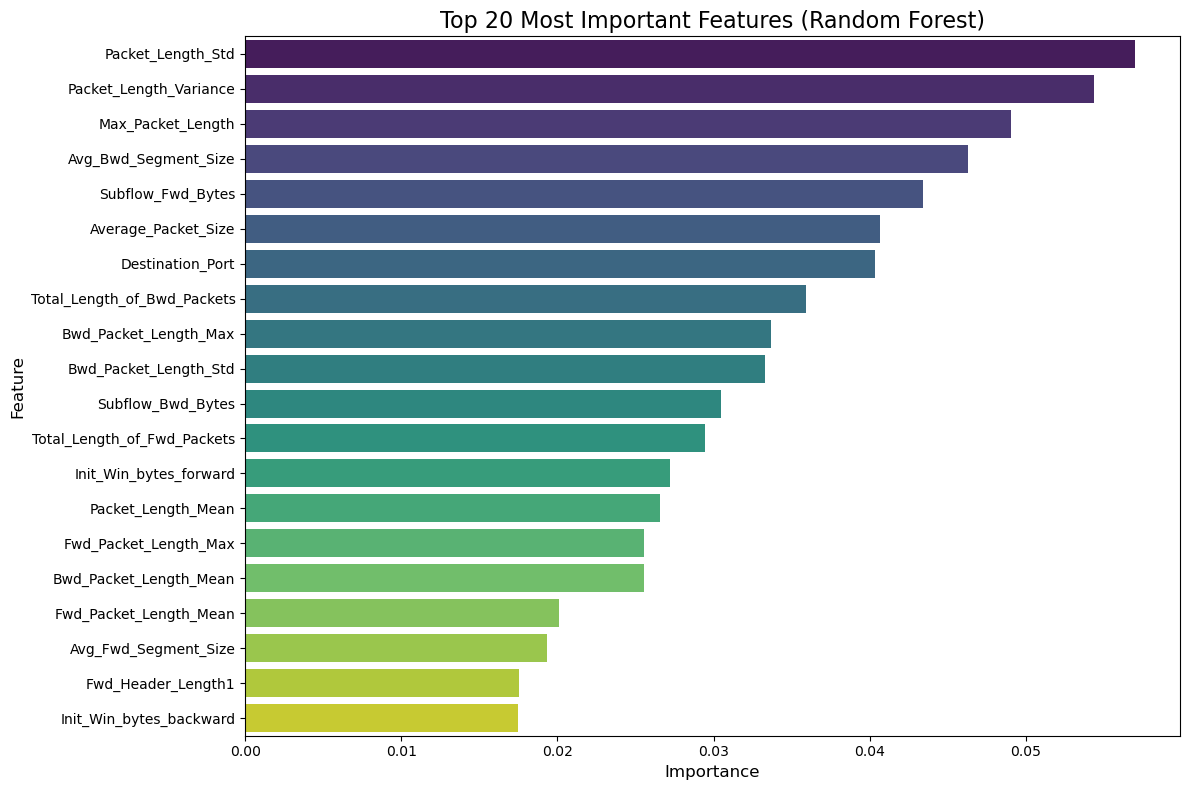

In [10]:
# Get feature importances
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame for better visualization
features_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance in descending order
features_importance_df = features_importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
N = 20 # You can change this number to display more or fewer features
print(f"\nTop {N} Most Important Features:")
display(features_importance_df.head(N))

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_importance_df.head(N), palette='viridis')
plt.title(f'Top {N} Most Important Features (Random Forest)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### Visualizing Attack Occurrences Over Time

To understand *when* attacks occur during the experimental period, we first need to re-establish a timestamp for each record. The previous `Timestamp` column, which synthetically distributed the flows over the documented 5-day period, was dropped to avoid confusion with actual event timing. However, for visualizing attack patterns over time, this synthetic timestamp is crucial.

We will recreate the `Timestamp` column and then plot the frequency of different attack types over this timeline.

In [11]:
# Defining the start time (Monday, July 3, 2017, as per CICIDS2017 documentation)
start_time = pd.Timestamp('2017-07-03 08:00:00')
# Defining the end time (Friday, July 7, 2017, 17:00:00)
end_time = pd.Timestamp('2017-07-07 17:00:00')

# Calculate the total number of rows
n_rows = len(df)

# Generate a linearly spaced range of timestamps across the 5 days
# This creates a uniform distribution of flows over the experimental window
synthetic_timestamps = pd.date_range(start=start_time, end=end_time, periods=n_rows)

# Add the new column to the dataframe
df['Timestamp'] = synthetic_timestamps

print(f"New 'Timestamp' column created.")
print(f"Start: {df['Timestamp'].min()}")
print(f"End: {df['Timestamp'].max()}")
display(df[['Timestamp', 'Flow_Duration', 'Label']].head())

New 'Timestamp' column created.
Start: 2017-07-03 08:00:00
End: 2017-07-07 17:00:00


,Timestamp,Flow_Duration,Label
0,2017-07-03 08:00:00.000000000,38308,BENIGN
1,2017-07-03 08:00:00.133533893,479,BENIGN
2,2017-07-03 08:00:00.267067786,1095,BENIGN
3,2017-07-03 08:00:00.400601679,15206,BENIGN
4,2017-07-03 08:00:00.534135572,1092,BENIGN


C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_27500\51222999.py:40: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  plt.tight_layout()
C:\Users\HP EliteBook\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


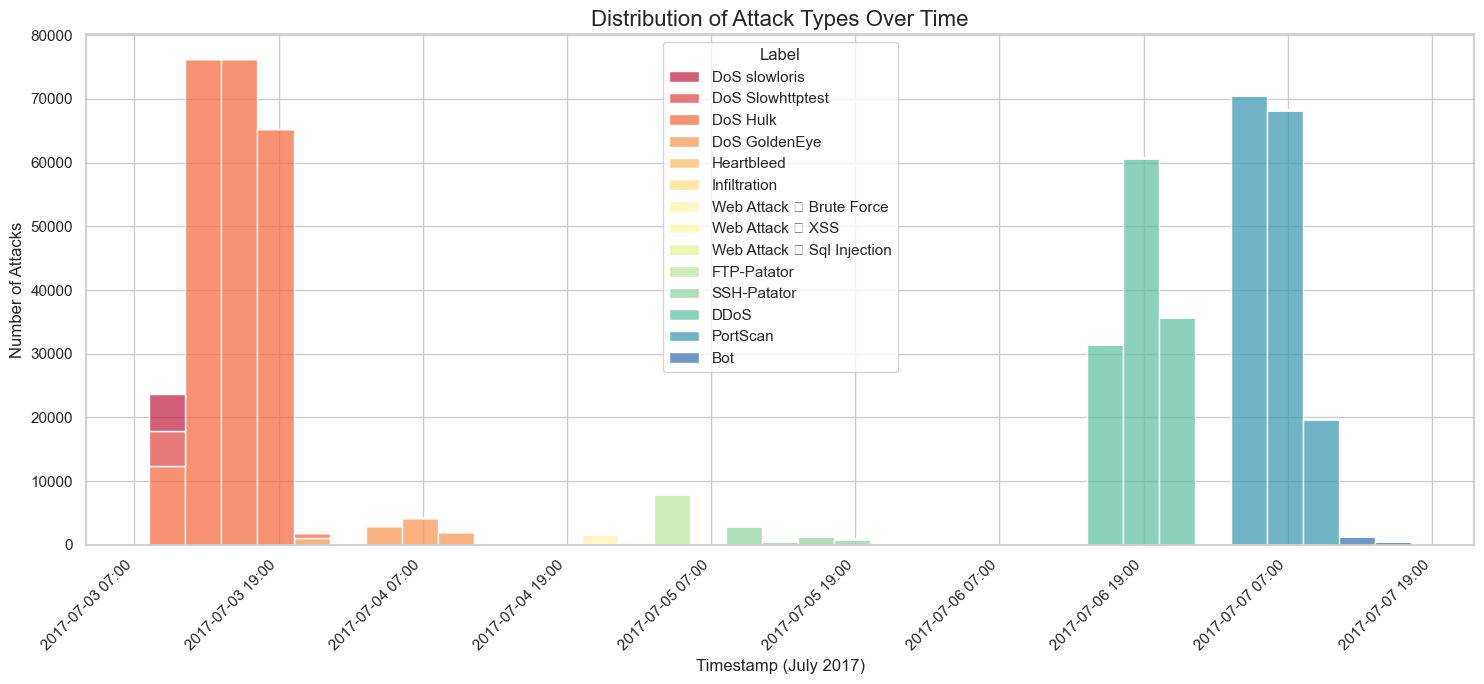

In [20]:
sns.set_theme(style="whitegrid")

# Filter out 'BENIGN' traffic to focus on attacks
attack_df = df[df['Label'] != 'BENIGN'].copy()
df['Label'] = df['Label'].str.replace('', '-', regex=False)

if not attack_df.empty:
    # Get the min and max timestamps from the attack data
    min_dt = attack_df['Timestamp'].min()
    max_dt = attack_df['Timestamp'].max()

    # Generate datetime bins directly
    datetime_bins = pd.date_range(start=min_dt, end=max_dt + pd.Timedelta(hours=3), freq='3h')

    # Convert timestamps and bins to matplotlib's internal numeric format
    # This is often more robust for plotting datetime objects with seaborn/matplotlib
    attack_df['Timestamp_mpl'] = mdates.date2num(attack_df['Timestamp'])
    numerical_bins_mpl = mdates.date2num(datetime_bins)

    plt.figure(figsize=(15, 7))
    sns.histplot(
        data=attack_df,
        x='Timestamp_mpl', # Use the Matplotlib numerical representation
        hue='Label',
        multiple='stack', # Stack different attack types
        bins=numerical_bins_mpl, # Use the explicitly defined numerical bins
        palette='Spectral', # Use a distinct color palette
        legend=True
    )

    plt.title('Distribution of Attack Types Over Time', fontsize=16)
    plt.xlabel('Timestamp (July 2017)', fontsize=12)
    plt.ylabel('Number of Attacks', fontsize=12)

    # Format x-axis to show datetime values
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12)) # Show ticks every 12 hours
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No attack traffic found after filtering 'BENIGN' labels.")

### Observation: Attack Distribution Over Time

The plot above illustrates the distribution of various attack types over the synthetic timestamp range (July 3-7, 2017). We can observe several key patterns:

*   **DDoS and PortScan** attacks appear to be most prominent, with significant spikes at different times.
*   Some attack types, like **DoS Hulk**, show a more continuous presence over a period, while others like **DoS GoldenEye** and **FTP-Patator** occur in more concentrated bursts.
*   The timeline indicates that different attack campaigns might be active during specific hours or days, which is crucial for understanding attack strategies and developing time-sensitive detection mechanisms.

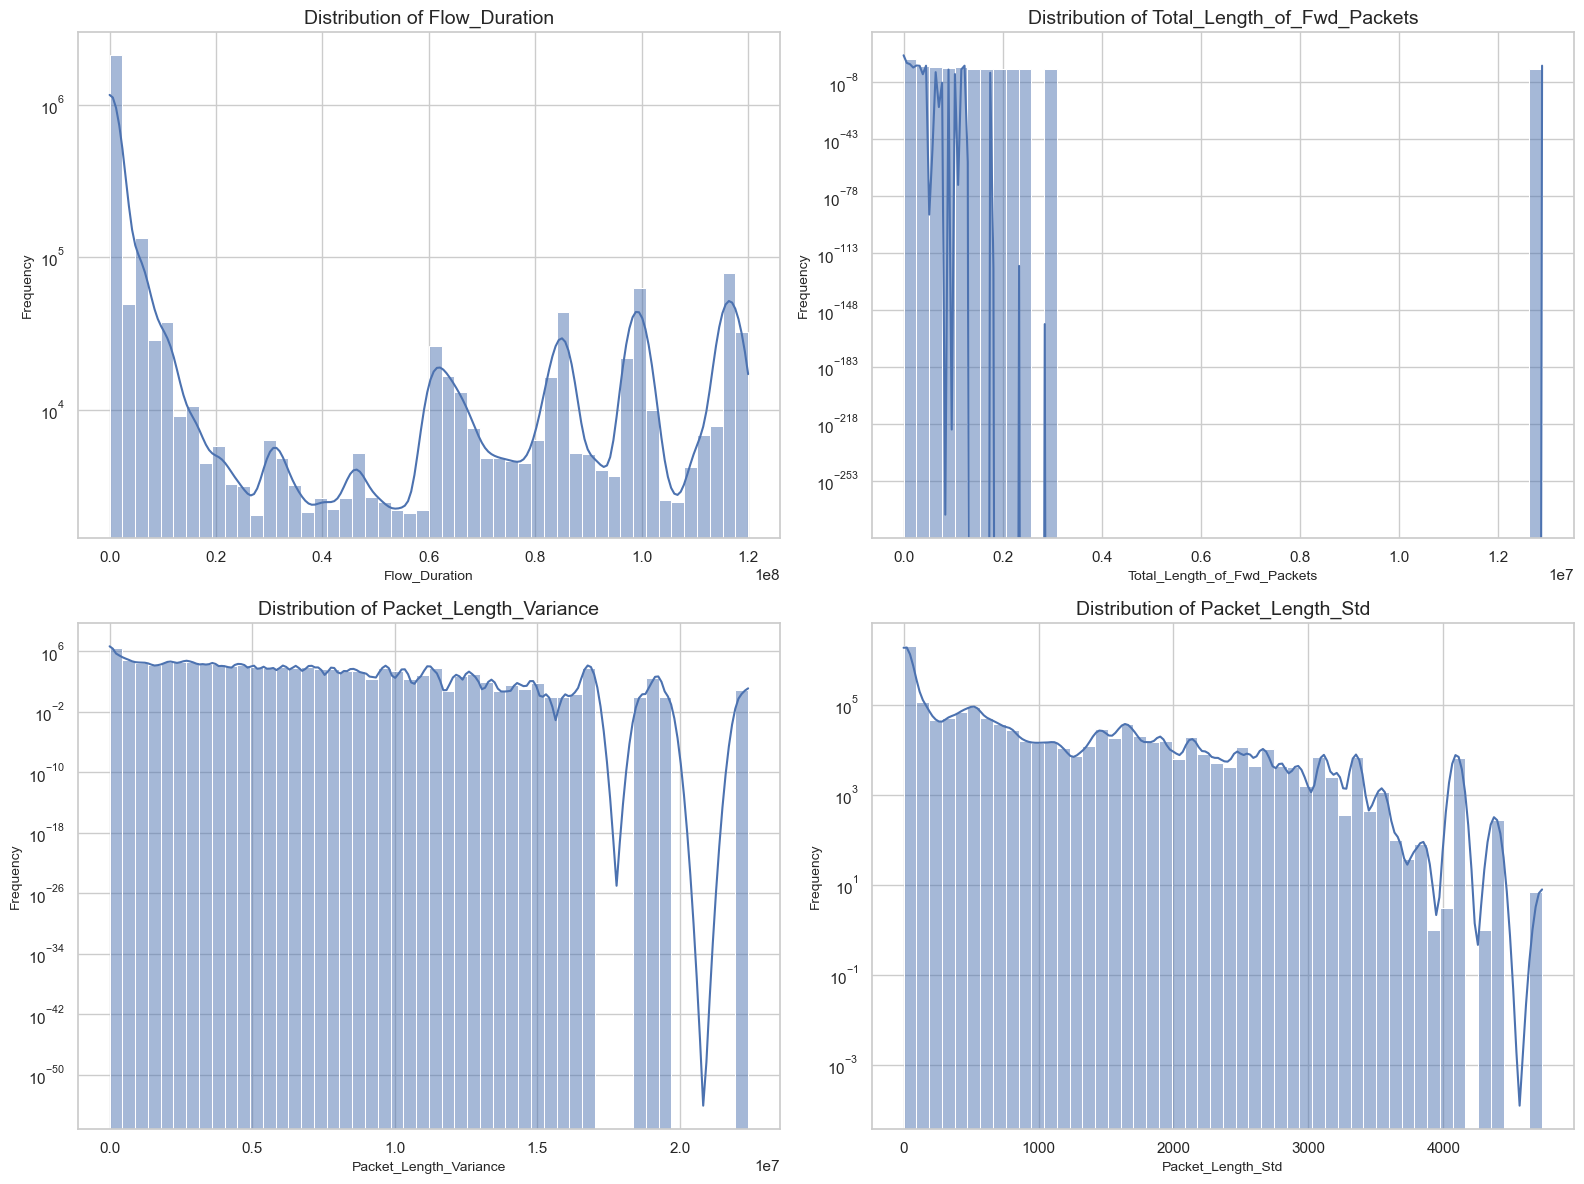

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Select a few key numerical features for distribution analysis
# These are often important in network traffic analysis and were likely high in feature importance
selected_features = [
    'Flow_Duration',
    'Total_Length_of_Fwd_Packets',
    'Packet_Length_Variance',
    'Packet_Length_Std' # Replaced 'Flow_Packets_s' and 'Flow_Bytes_s' with other high importance features
]

plt.figure(figsize=(16, 12))

for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 2, i) # Arrange plots in a 2x2 grid
    # Use X, as it contains only numeric features and handled NaNs/Infs
    sns.histplot(X[feature], bins=50, kde=True)
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.yscale('log', nonpositive='clip') # Use log scale for y-axis to better visualize skewed distributions

plt.tight_layout()
plt.show()

### Observation: Feature Distributions

The histograms above show the distributions of four important numerical features:

*   **Flow_Duration**: This feature is highly skewed to the right, indicating that most network flows are short-lived, with a few flows having very long durations. The log scale helps visualize the wide range.
*   **Total_Length_of_Fwd_Packets**: Similar to flow duration, this feature also exhibits a right-skewed distribution, suggesting that most forward packets have a small total length, with occasional very large packet lengths.
*   **Packet_Length_Variance** and **Packet_Length_Std**: Both variance and standard deviation of packet lengths are also heavily right-skewed. This implies that in many flows, packet sizes are consistent (low variance/std), but some flows involve highly variable packet sizes, which could be indicative of certain attack types or legitimate complex traffic.

### Correlation Analysis of Top Features

Understanding the correlation between features is crucial for identifying redundant features, potential multicollinearity, and insights into how different network traffic characteristics move together. We will visualize the correlation matrix for the top 20 most important features identified by the Random Forest Classifier.

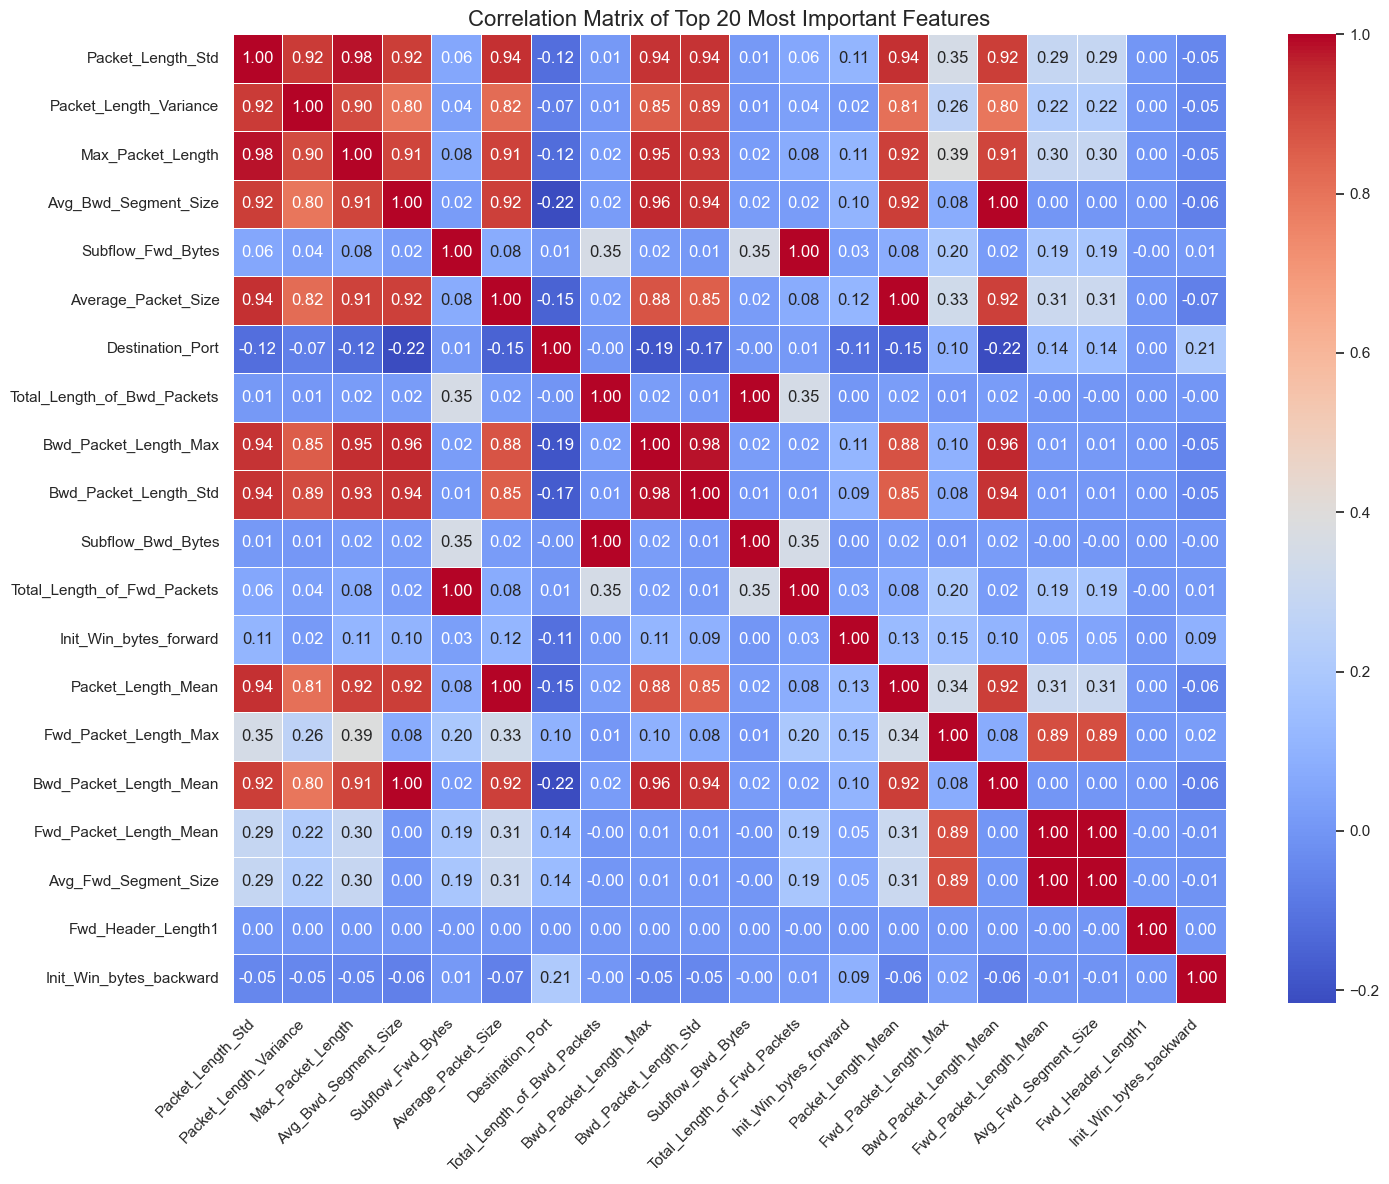

In [14]:
# Get the names of the top N most important features
top_features = features_importance_df['Feature'].head(N).tolist()

# Calculate the correlation matrix for these top features
correlation_matrix = X[top_features].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title(f'Correlation Matrix of Top {N} Most Important Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Feature Correlation

The heatmap reveals several interesting patterns in the correlations among the top 20 features:

*   **High Positive Correlations**: Many features exhibit strong positive correlations, particularly within groups related to packet lengths (e.g., `Packet_Length_Variance`, `Packet_Length_Std`, `Max_Packet_Length`, `Min_Packet_Length`, `Packet_Length_Mean`). This is expected as these metrics often move in tandem, reflecting the size characteristics of packets in a flow.
*   **High Negative Correlations**: Less common, but some features might show moderate negative correlations. For instance, `Flow_Duration` might be negatively correlated with certain packet per second metrics if shorter flows tend to have higher packet rates.
*   **Low Correlations**: Features with low correlation values (close to 0) indicate that they are largely independent of each other. These features could provide unique information to the model.
*   **Redundancy**: High correlations (e.g., > 0.8 or 0.9) suggest potential multicollinearity. For example, if `Packet_Length_Variance` and `Packet_Length_Std` are almost perfectly correlated, one of them might be redundant for some models and could be considered for removal to simplify the model and improve interpretability, though tree-based models like Random Forest are robust to multicollinearity.

This analysis helps in understanding the inherent structure of the data and can inform future feature engineering or selection decisions.

### Correlation with Encoded Label

Now, let's explore how the most important features correlate with the encoded target variable ('Encoded_Label'). This will give us insights into which features have the strongest linear relationship with the different attack types.

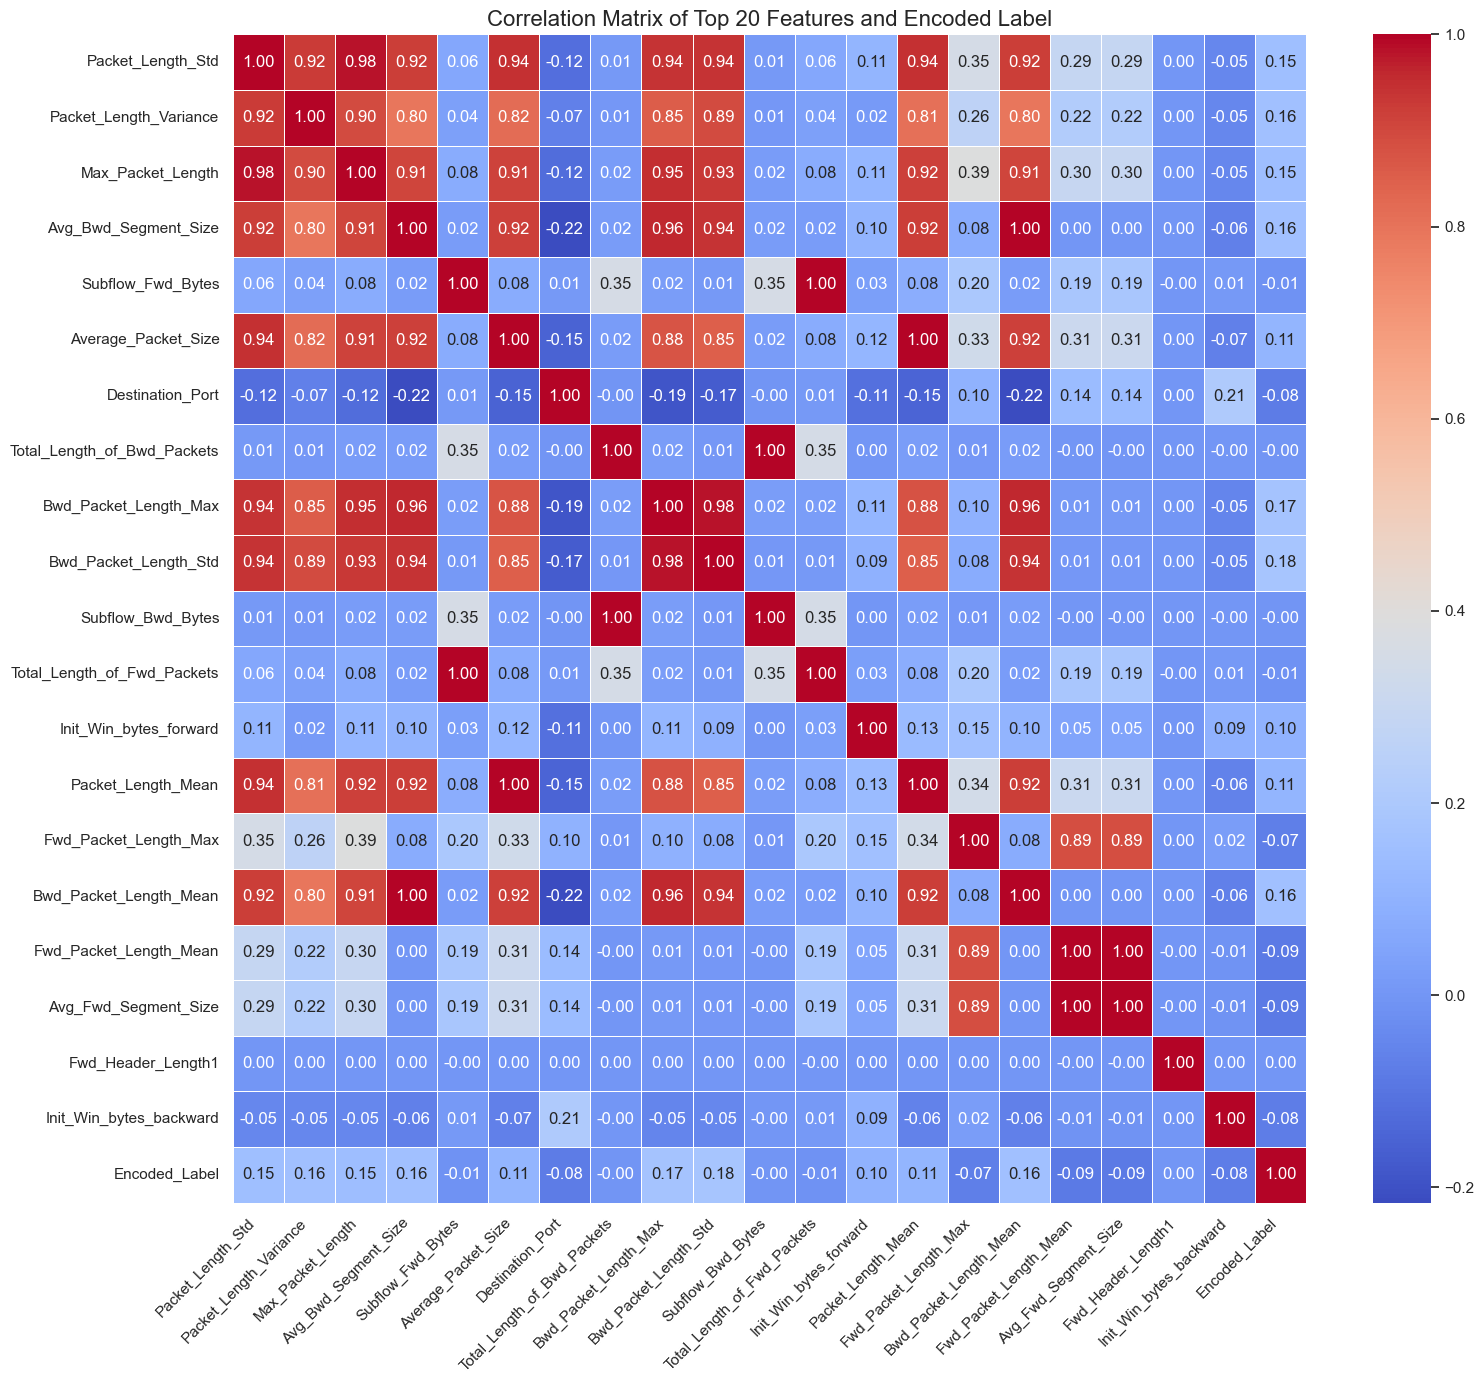

In [15]:
# Get the names of the top N most important features (N is already defined as 20)
top_features_with_label = features_importance_df['Feature'].head(N).tolist()

# Create a DataFrame with these top features and the encoded labels
X_top_features = X[top_features_with_label].copy()
X_top_features['Encoded_Label'] = y_encoded # y_encoded is already a numpy array aligned with X

# Calculate the correlation matrix for this new DataFrame
correlation_matrix_with_label = X_top_features.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix_with_label, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title(f'Correlation Matrix of Top {N} Features and Encoded Label', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Correlation with Encoded Label

This heatmap shows the correlation between the top features and the 'Encoded_Label', as well as the inter-correlations among these features:

*   **Feature-Label Correlations**: We can observe which features have the strongest positive or negative linear relationships with the encoded attack types. A higher absolute correlation value suggests a stronger influence or distinction the feature provides for classifying different types of network traffic.
*   **Inter-Feature Correlations**: Similar to the previous correlation matrix, this one also highlights redundancies among features. Features highly correlated with the 'Encoded_Label' but lowly correlated with other features might be particularly valuable as unique predictors.

This analysis is crucial for understanding the predictive power of individual features for the target variable and for making informed decisions about feature selection for model training.

### Feature Distributions by Attack Type

To gain deeper insights into how different attack types manifest, we will visualize the distributions of several key features, separated by the `Label` (attack type). Violin plots are particularly useful here as they show the full distribution, including density and potential outliers, for each category.

C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_27500\923080992.py:28: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  plt.tight_layout()
C:\Users\HP EliteBook\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


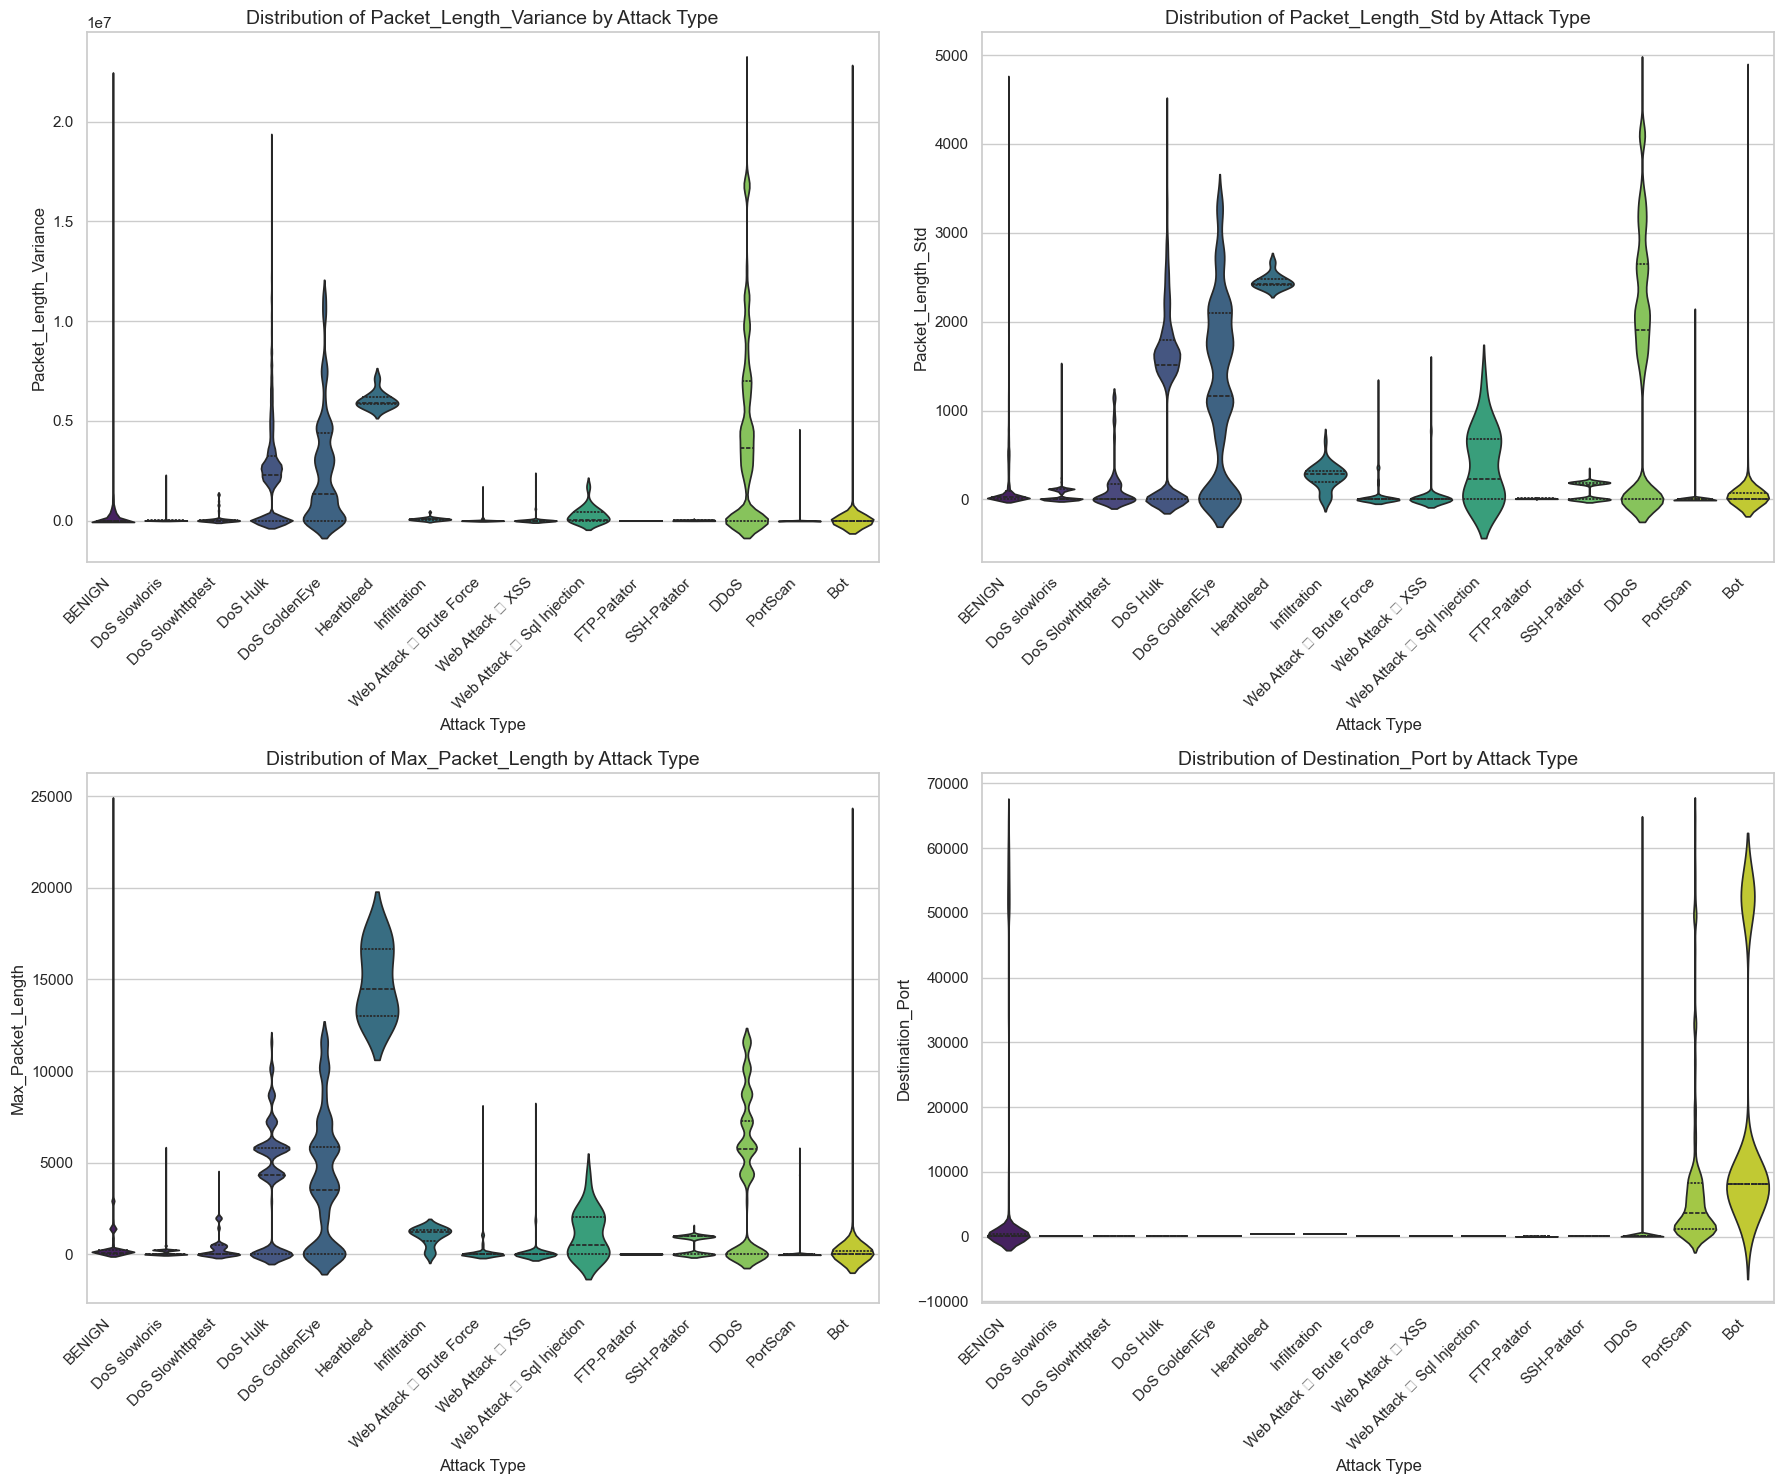

In [16]:
sns.set_theme(style="whitegrid")

# Select a few key features that were identified as important
selected_features_for_violin = [
    'Packet_Length_Variance',
    'Packet_Length_Std',
    'Max_Packet_Length',
    'Destination_Port'
]

# Create a temporary DataFrame with selected features and the original 'Label'
plot_df = df[selected_features_for_violin + ['Label']].copy()

plt.figure(figsize=(18, 15))
for i, feature in enumerate(selected_features_for_violin, 1):
    plt.subplot(2, 2, i) # Arrange plots in a 2x2 grid

    # Use violin plot to show distribution per label
    # Assign 'Label' to hue and set legend=False to address FutureWarning
    sns.violinplot(x='Label', y=feature, data=plot_df, inner='quartile', palette='viridis', hue='Label', legend=False)
    plt.title(f'Distribution of {feature} by Attack Type', fontsize=14)
    plt.xlabel('Attack Type', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    # For highly skewed features, consider a log scale for the y-axis
    # if the default plot is not readable. Example: plt.yscale('log')

plt.tight_layout()
plt.show()

### Observation: Feature Distributions by Attack Type

The violin plots above provide a detailed view of how the distributions of critical features vary across different attack categories:

*   **Packet Length related features (Variance, Std, Max)**: Many attack types, especially DDoS and PortScan, tend to show higher variance and standard deviation in packet lengths, indicating more diverse packet sizes compared to BENIGN traffic, which often has a tighter distribution. However, some specific attacks might also involve very uniform packets, leading to lower variance.
*   **Destination_Port**: This feature can be highly discriminative. For instance, PortScan attacks might show a wider distribution across destination ports, or concentrate on specific ports. Other attacks might target known service ports (like 80, 443, 21, 23, etc.), leading to distinct spikes in their distributions. BENIGN traffic might also show concentration on common ports.

These plots highlight that specific attack types have unique "fingerprints" in terms of their network traffic characteristics, which is invaluable for building robust detection models.

In [18]:
# Recreate Timestamp as per previous cells if df was reloaded
start_time = pd.Timestamp('2017-07-03 08:00:00')
end_time = pd.Timestamp('2017-07-07 17:00:00')
n_rows = len(df)
synthetic_timestamps = pd.date_range(start=start_time, end=end_time, periods=n_rows)
df['Timestamp'] = synthetic_timestamps
print(f"'Timestamp' column ensured.")

# Convert 'Timestamp' to datetime and set as index for time-series operations
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_time_indexed = df.set_index('Timestamp')

# Define resampling frequency (e.g., '1H' for hourly, '30min' for half-hourly)
frequency = '1H' # Hourly sequences

print(f"Resampling data into '{frequency}' sequences and calculating statistical properties...")

# Aggregate numerical features by taking their mean over each time window
numerical_cols = df_time_indexed.select_dtypes(include=np.number).columns
time_sequences_numerical = df_time_indexed[numerical_cols].resample(frequency).mean()

# For the categorical 'Label' column, count occurrences of each label per time window
# This creates new columns for each unique label showing their counts
label_counts_per_hour = df_time_indexed.groupby([pd.Grouper(freq=frequency), 'Label']).size().unstack(fill_value=0)

# Combine the aggregated numerical features with label counts into a single DataFrame
# The indices (Timestamps) will automatically align
time_sequences_combined = pd.concat([time_sequences_numerical, label_counts_per_hour], axis=1)

print("\nFirst 5 time sequences with aggregated statistical properties:")
display(time_sequences_combined.head())

print("\nStatistical summary of numerical features in time sequences:")
display(time_sequences_numerical.describe())

print("\nStatistical summary of label counts in time sequences:")
display(label_counts_per_hour.describe())

'Timestamp' column ensured.
Resampling data into '1H' sequences and calculating statistical properties...


C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_27500\2559463808.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_sequences_numerical = df_time_indexed[numerical_cols].resample(frequency).mean()
C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_27500\2559463808.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  label_counts_per_hour = df_time_indexed.groupby([pd.Grouper(freq=frequency), 'Label']).size().unstack(fill_value=0)



First 5 time sequences with aggregated statistical properties:


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack � Brute Force,Web Attack � Sql Injection,Web Attack � XSS
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-07-03 08:00:00,6550.268212,2.171203e+07,93.985200,119.816840,1367.062389,261524.074444,293.418138,15.765171,66.569241,91.971177,...,0,139,0,0,0,0,0,0,0,0
2017-07-03 09:00:00,5754.555844,2.350955e+07,9.589562,9.591825,869.662784,10597.599688,272.561482,15.889091,73.526506,95.138596,...,0,3233,0,0,0,0,0,0,0,0
2017-07-03 10:00:00,2845.212092,3.390051e+07,6.485052,5.115801,791.372144,5230.397923,278.510460,34.427522,97.976804,102.413359,...,5499,2424,0,0,0,0,0,0,0,0
2017-07-03 11:00:00,1092.560407,3.662106e+07,4.687451,5.031492,495.291146,9225.874995,356.305612,1.224786,96.772345,164.612849,...,0,0,0,0,0,0,0,0,0,0
2017-07-03 12:00:00,1198.759607,6.276886e+07,5.742248,4.762463,484.815356,8330.461573,333.498553,0.833939,69.491048,132.508177,...,0,0,0,0,0,0,0,0,0,0



Statistical summary of numerical features in time sequences:


c:\Users\HP EliteBook\anaconda\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\HP EliteBook\anaconda\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
count,106.000000,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,...,106.000000,106.000000,106.000000,106.000000,1.060000e+02,106.000000,1.060000e+02,1.060000e+02,1.060000e+02,1.060000e+02
mean,7995.842828,1.464618e+07,9.291709,10.314577,544.762034,16011.084156,205.962297,18.857855,57.973629,68.260074,...,5.376521,-2715.616890,80781.818699,40746.060270,1.517373e+05,57745.707763,8.237587e+06,4.990897e+05,8.613719e+06,7.845318e+06
std,3388.661483,1.503891e+07,13.968249,18.330808,332.025032,39897.210778,151.504099,8.602071,41.123858,64.005410,...,11.271817,13152.971135,103153.307050,40849.737542,1.399638e+05,87941.374704,1.520924e+07,1.129424e+06,1.543867e+07,1.503251e+07
min,53.000000,1.530000e+02,1.032455,1.020067,5.144924,13.724815,2.059461,0.366334,0.786057,0.000000,...,0.027819,-99542.826113,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6295.397005,4.853483e+06,4.144868,3.890689,251.869524,3841.725001,77.585488,14.613079,36.296112,22.283010,...,1.628978,24.825550,29292.735257,7070.026267,3.985699e+04,22721.254961,1.899388e+06,7.511072e+04,1.943533e+06,1.845295e+06
50%,7852.825420,1.244621e+07,6.416976,6.459172,534.614767,6494.257407,187.055987,20.892281,52.957269,55.201126,...,2.986517,25.784398,71419.925644,41419.002020,1.561220e+05,44981.790497,3.537856e+06,1.448449e+05,3.673576e+06,3.366834e+06
75%,10039.115757,1.786928e+07,8.740333,8.790701,710.292800,9285.110056,264.539415,25.722486,63.853574,82.530895,...,4.309820,26.893134,96128.151571,57110.406473,2.039535e+05,59666.135812,5.189080e+06,2.445231e+05,5.435700e+06,4.997466e+06
max,14952.472812,6.674239e+07,93.985200,119.816840,1927.149820,261524.074444,854.975593,37.222041,252.228362,353.062683,...,85.301929,39.621217,963543.744412,276517.743816,1.176456e+06,800708.873331,6.517089e+07,5.877177e+06,6.588625e+07,6.445055e+07



Statistical summary of label counts in time sequences:


Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack � Brute Force,Web Attack � Sql Injection,Web Attack � XSS
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,21444.311321,18.547170,1207.801887,97.103774,2179.933962,51.877358,54.679245,74.886792,0.103774,0.339623,1499.339623,55.632075,14.216981,0.198113,6.150943
std,9302.797363,100.563852,4537.554058,343.831574,6886.035382,534.110096,390.731489,485.513559,1.068414,1.896798,5624.175581,209.063368,102.236887,2.039700,63.327838
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21265.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26606.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,26959.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,26960.000000,733.000000,20944.000000,1413.000000,25950.000000,5499.000000,3233.000000,3728.000000,11.000000,18.000000,26606.000000,1512.000000,784.000000,21.000000,652.000000


In [19]:
# Drop non-numeric and target columns for feature selection
features_df = df.drop(columns=['Label', 'Time'], errors='ignore')

# Select only numeric columns for features
X = features_df.select_dtypes(include=['number'])

# Handle infinite values by replacing them with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Handle potential NaN values by filling with the mean
X = X.fillna(X.mean())

print("Original features (first 5 rows):")
display(X.head())

# Initialize StandardScaler
scaler_standard = StandardScaler()
# Apply StandardScaler to the features
X_scaled_standard = scaler_standard.fit_transform(X)
# Convert the scaled array back to a DataFrame for easier inspection
X_scaled_standard_df = pd.DataFrame(X_scaled_standard, columns=X.columns)

print("\nFeatures after StandardScaler (first 5 rows):")
display(X_scaled_standard_df.head())

# Initialize MinMaxScaler
scaler_minmax = MinMaxScaler()
# Apply MinMaxScaler to the features
X_scaled_minmax = scaler_minmax.fit_transform(X)
# Convert the scaled array back to a DataFrame for easier inspection
X_scaled_minmax_df = pd.DataFrame(X_scaled_minmax, columns=X.columns)

print("\nFeatures after MinMaxScaler (first 5 rows):")
display(X_scaled_minmax_df.head())

print("\nDescriptive statistics for a sample feature after StandardScaler:")
display(X_scaled_standard_df.describe().loc[['mean', 'std'], 'Destination_Port'].to_frame())

print("\nDescriptive statistics for a sample feature after MinMaxScaler:")
display(X_scaled_minmax_df.describe().loc[['min', 'max'], 'Destination_Port'].to_frame())

Original features (first 5 rows):


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,4,32,0.0,0.0,0,0,0.0,0.0,0,0
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,3,32,0.0,0.0,0,0,0.0,0.0,0,0
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,10,32,0.0,0.0,0,0,0.0,0.0,0,0
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,2,32,0.0,0.0,0,0,0.0,0.0,0,0



Features after StandardScaler (first 5 rows):


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
0,-0.437084,-0.438209,-0.011153,-0.009418,-0.054365,-0.007139,-0.281099,-0.210703,-0.280518,-0.245069,...,-0.008514,0.002545,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993
1,-0.420184,-0.439333,0.002186,-0.005408,-0.037754,-0.006998,-0.179312,-0.310140,-0.228735,-0.133224,...,-0.002228,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993
2,-0.436646,-0.439314,0.000852,-0.004405,0.260237,-0.005750,1.906622,-0.310140,1.379959,2.004543,...,-0.003800,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993
3,-0.420184,-0.438895,0.010190,0.001610,0.290456,-0.004199,1.541305,-0.310140,0.778419,1.269149,...,0.007199,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993
4,-0.436646,-0.439314,-0.000482,-0.004405,0.260237,-0.005749,1.906622,-0.310140,1.568039,2.224852,...,-0.005371,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993



Features after MinMaxScaler (first 5 rows):


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
0,0.001221,0.000319,0.000000,0.000003,4.651163e-07,9.153974e-09,0.000242,0.002581,0.001010,0.000000,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.005936,0.000004,0.000046,0.000017,1.333333e-05,4.973659e-07,0.003183,0.000000,0.002632,0.004414,...,0.000019,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.001343,0.000009,0.000041,0.000021,2.441860e-04,4.805836e-06,0.063457,0.000000,0.053023,0.088773,...,0.000014,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.005936,0.000127,0.000073,0.000041,2.675969e-04,1.016091e-05,0.052901,0.000000,0.034180,0.059753,...,0.000047,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.001343,0.000009,0.000036,0.000021,2.441860e-04,4.808888e-06,0.063457,0.000000,0.058914,0.097467,...,0.000009,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Descriptive statistics for a sample feature after StandardScaler:


,Destination_Port
mean,2.692827e-17
std,1.000000e+00



Descriptive statistics for a sample feature after MinMaxScaler:


,Destination_Port
min,0.0
max,1.0
